<a href="https://colab.research.google.com/github/tensorbytes0202/Sequene-Models_case_studies/blob/main/Sentiment_Classification_on_IMDB_Reviews_using_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Build a Deep Learning model using LSTM (Long Short-Term Memory) to classify IMDB movie reviews as:

Positive Review
Negative Review

Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Load IMDB Dataset

In [3]:
# Vocabulary size
VOCAB_SIZE = 10000

# Load dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

print("Training Samples :", len(X_train))
print("Testing Samples  :", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training Samples : 25000
Testing Samples  : 25000


In [4]:
print(X_train[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [5]:
print(y_train[:10])

[1 0 0 1 0 0 1 0 1 0]


In [6]:
MAX_LEN = 200

X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

print(X_train.shape)
print(X_test.shape)

(25000, 200)
(25000, 200)


In [7]:
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=VOCAB_SIZE,
                    output_dim=128,
                    input_length=MAX_LEN))

# First LSTM Layer
model.add(LSTM(128, return_sequences=False))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(monitor='val_loss',patience=2,restore_best_weights=True)

In [11]:
histroy = model.fit(X_train,y_train,epochs=10,batch_size=64,validation_split=0.2,callbacks=[early_stop])

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.7871 - loss: 0.4450 - val_accuracy: 0.8508 - val_loss: 0.3402
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.8946 - loss: 0.2648 - val_accuracy: 0.8714 - val_loss: 0.3371
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9294 - loss: 0.1894 - val_accuracy: 0.8542 - val_loss: 0.3506
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9338 - loss: 0.1732 - val_accuracy: 0.8578 - val_loss: 0.3898


In [12]:
loss,accuracy = model.evaluate(X_test,y_test)
print("Test Loss :", loss)
print("Test Accuracy :",accuracy)


782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8609 - loss: 0.3594
Test Loss : 0.3593653440475464
Test Accuracy : 0.8609200119972229


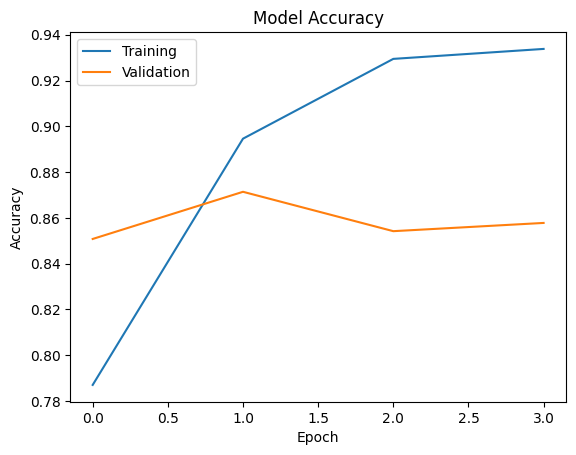

In [13]:
plt.plot(histroy.history['accuracy'])
plt.plot(histroy.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(['Training','Validation'])

plt.show()

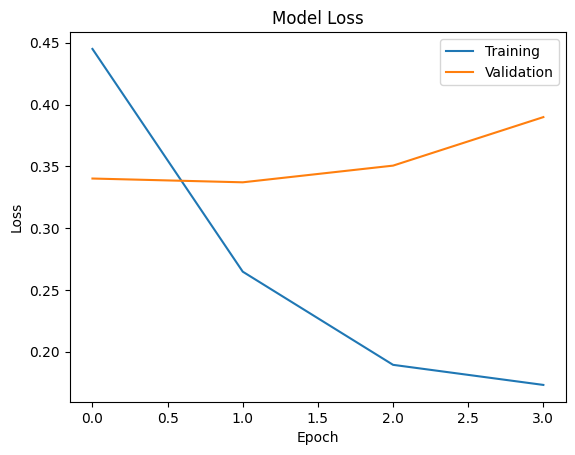

In [14]:
plt.plot(histroy.history['loss'])
plt.plot(histroy.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend(['Training', 'Validation'])

plt.show()


In [15]:
word_index = imdb.get_word_index()

reverse_word_index = {
    value : key for key,value in word_index.items()

}

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [20]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer(num_words=VOCAB_SIZE)

def predict_sentiment(text):
  sequences = tokenizer.texts_to_sequences([text])
  padded = pad_sequences(sequences,maxlen=MAX_LEN)

  prediction = model.predict(padded)

  if prediction[0][0] > 0.5:
    print("Positive Review")
  else:
    print("Negative Review")


In [21]:
predict_sentiment("This movie was amazing and acting was fantastic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Positive Review
